In [9]:
import sys
import os
sys.path.append('../data/toy_datasets/')
from toyDataWithDensity import make_circle_varying_density
from implementation_validation import generate_validation_panel_data

### Validation on Uniform Circle

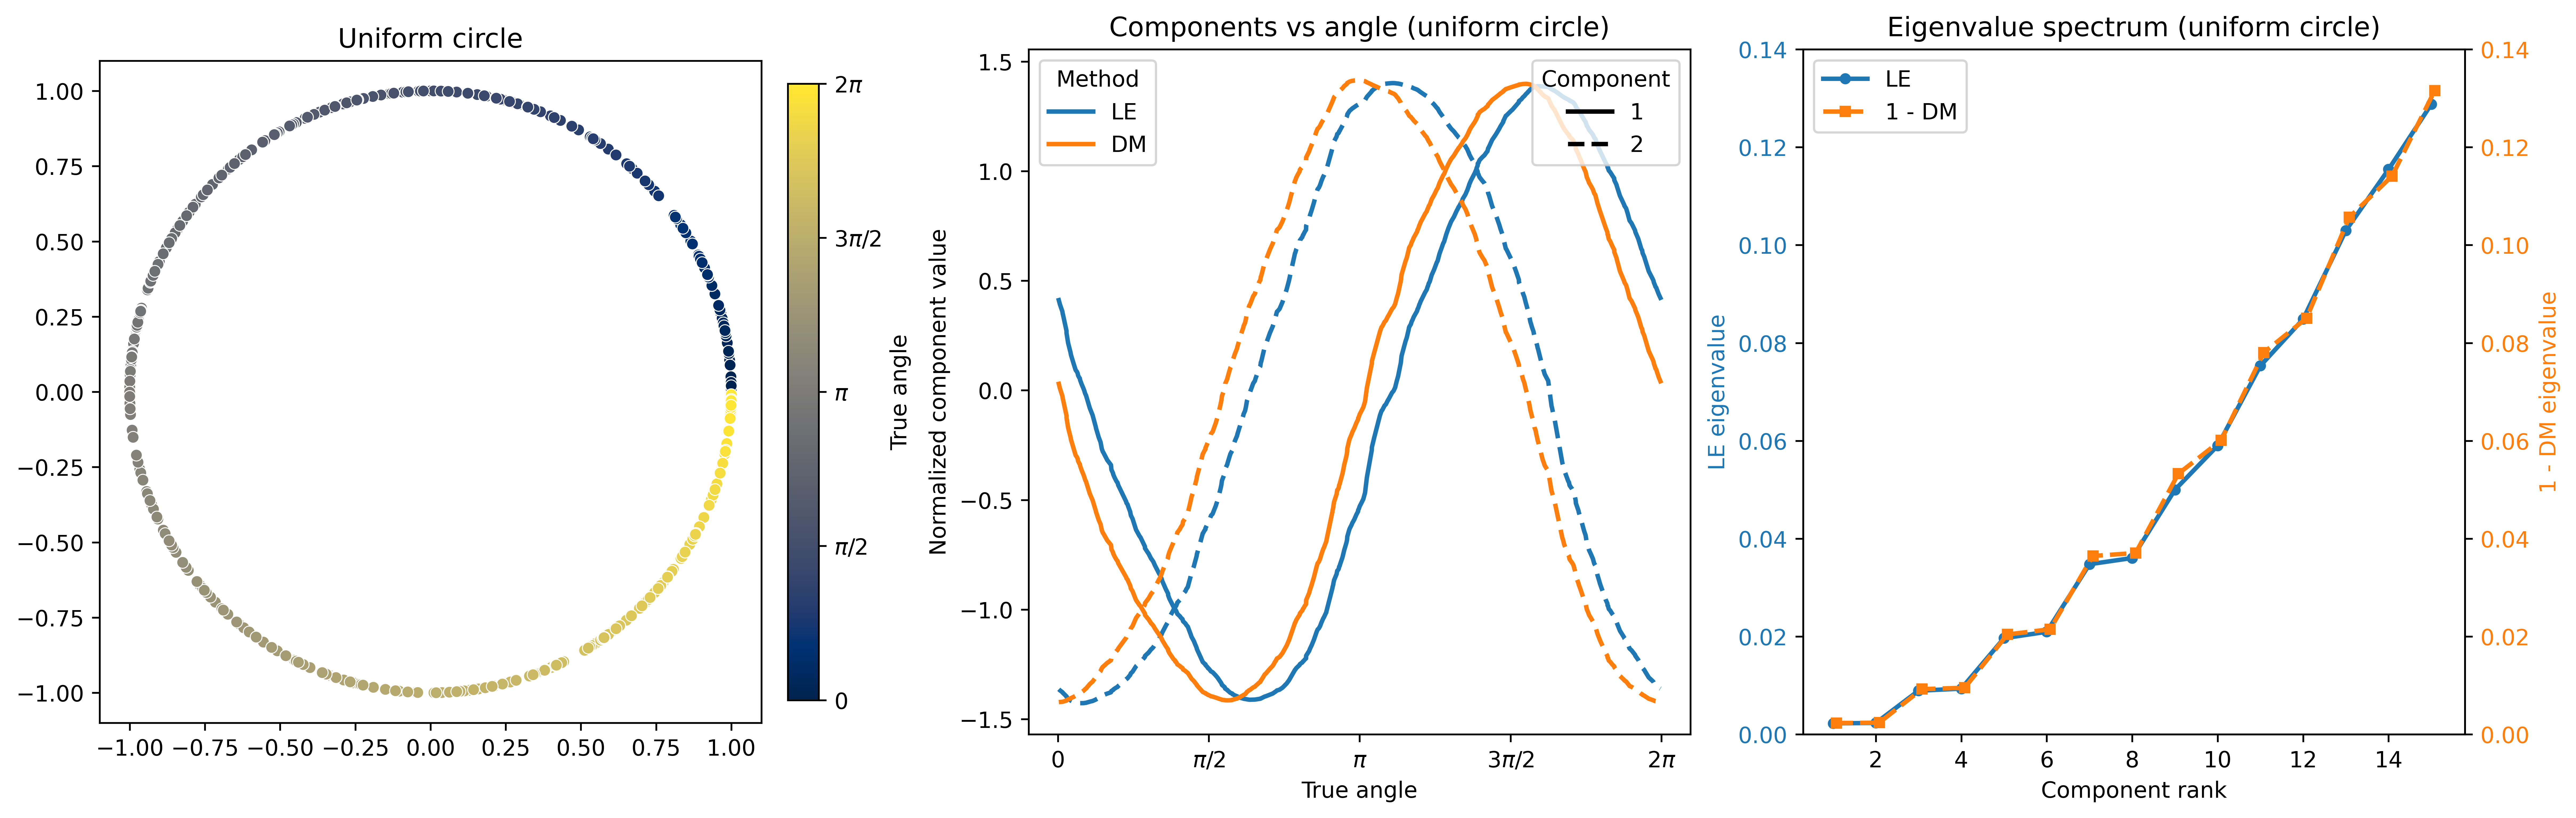

In [163]:
adata_val, comp_df, spec_df = generate_validation_panel_data(n_points=500,drop_trivial=True,n_components=15)

# SUPPLEMENTAL FIGURE ON PERFECT CIRCLE
# NOTE: may have to run this a few times to get the sine cosine to be in the same orientation so that they align nicely
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    sharey=False,
    constrained_layout=True,
    dpi=600
)

# -----------------------------
# Panel 1: uniform circle
# -----------------------------
ax = axes[0]
norm = plt.Normalize(adata_val.obs["angle"].min(), adata_val.obs["angle"].max())

sns.scatterplot(
    x=adata_val.X[:, 0],
    y=adata_val.X[:, 1],
    hue=adata_val.obs["angle"],
    palette="cividis",
    hue_norm=norm,
    ax=ax,
    legend=False,
    s=28,
)

ax.set_title("Uniform circle")
ax.set_aspect("equal", adjustable="box")

max_range = np.max(np.abs(adata_val.X[:, :2])) + 0.1
ax.set_xlim([-max_range, max_range])
ax.set_ylim([-max_range, max_range])

sm = plt.cm.ScalarMappable(cmap="cividis", norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, label="True angle", shrink=0.9, fraction=0.05, pad=0.04)
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
cb.set_ticks(ticks)
cb.set_ticklabels(labels)

# -----------------------------
# Panel 2: first two nontrivial components vs angle
# -----------------------------
ax = axes[1]

# work on a copy so the original dataframe is not modified
comp_plot = comp_df.copy()

# normalize within each Method x component curve
comp_plot["value"] = (
    comp_plot.groupby(["Method", "component"])["value"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

sns.lineplot(
    data=comp_plot,
    x="angle",
    y="value",
    hue="Method",
    style="component",
    palette={"LE": "#1f77b4", "DM": "#ff7f0e"},
    dashes={1: "", 2: (4, 2)},
    linewidth=2.0,
    ax=ax,
)

ax.set_title("Components vs angle (uniform circle)")
ax.set_xlabel("True angle")
ax.set_ylabel("Normalized component value")
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

# optional: cleaner legend with separate method/component encoding
if ax.legend_ is not None:
    ax.legend_.remove()

method_handles = [
    Line2D([0], [0], color="#1f77b4", lw=2, label="LE"),
    Line2D([0], [0], color="#ff7f0e", lw=2, label="DM"),
]
component_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="1"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="2"),
]

leg1 = ax.legend(handles=method_handles, title="Method", loc="upper left", frameon=True)
ax.add_artist(leg1)
ax.legend(handles=component_handles, title="Component", loc="upper right", frameon=True)

# -----------------------------
# Panel 3: dual-axis eigenvalue spectrum
# -----------------------------
ax1 = axes[2]

spec_plot = spec_df[spec_df["component_rank"] <= 15].copy()

le = spec_plot[spec_plot["Method"] == "LE"].sort_values("component_rank")
dm = spec_plot[spec_plot["Method"] == "DM"].sort_values("component_rank")

offset = 0.08  # small x-offset so overlapping curves are visible

# left axis: LE eigenvalues
line1 = ax1.plot(
    le["component_rank"],
    le["eigenvalue"],
    color="#1f77b4",
    marker="o",
    markersize=4,
    linewidth=2,
    label="LE",
)
ax1.set_xlabel("Component rank")
ax1.set_ylabel("LE eigenvalue", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_title("Eigenvalue spectrum (uniform circle)")

# right axis: 1 - DM eigenvalue
ax2 = ax1.twinx()
line2 = ax2.plot(
    dm["component_rank"] + offset,
    1 - dm["eigenvalue"],
    color="#ff7f0e",
    linestyle="--",
    marker="s",
    markersize=4,
    linewidth=2,
    label="1 - DM",
)
ax2.set_ylabel("1 - DM eigenvalue", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
ax1.set_ylim(0, 0.14)
ax2.set_ylim(0, 0.14)
# combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True)


plt.show()

### Plot density/noise experiment results

##### Generate Noisy Circle Example Data

In [18]:
sys.path.append('../trajectory_inference/')
import anndata as ad
import numpy as np
import pandas as pd
from diffusion_maps import kTilde, diffusion_map_from_Ktilde
from Laplacian_Eigenmaps import loadAndCSR, laplacianEigenmaps
from trajectory_validation import align_circular_pseudotime, aligned_circular_agreement
from density_experiment import radius_cv, mean_abs_wrapped_error

density_df = make_circle_varying_density(density_ratio=4,noise=0.35)
density_df
obs = density_df[['angle']].copy()
obs.index = [f"k{20}_noise{0.3}_dr{4}_seed{0}_cell{i}" for i in range(len(obs))]
adata = ad.AnnData(X=density_df[['x', 'y']].to_numpy(), obs=obs)
adata.obs['noise'] = 0.35
adata.obs['density_ratio'] = 4
adata.obs['n_points'] = 500
adata.obs['k'] = 20
adata.obsm['X_pca'] = adata.X

# initialize CSR
csr = loadAndCSR(adata, k=20, weighting='raw')
# LE
lap, eigvals = laplacianEigenmaps(csr, nComponents=5)

# DM
kT = kTilde(csr,alpha=0.5)
diff, lambdas, psis = diffusion_map_from_Ktilde(kT, n_components=5)

# center data
lap = lap - lap.mean(axis=0)
adata.obsm['lap_embed'] = lap
diff = diff - diff.mean(axis=0)
adata.obsm['dm_embed'] = diff

# compute aligned pseudotime
dpt = np.arctan2(diff[:,0],diff[:,1])
dpt = align_circular_pseudotime(adata.obs['angle'],dpt)['aligned']

lpt = np.arctan2(lap[:,0],lap[:,1])
lpt = align_circular_pseudotime(adata.obs['angle'],lpt)['aligned']

adata.obs['lpt'] = lpt
adata.obs['dpt'] = dpt

# record metrics
mwe = [mean_abs_wrapped_error(adata.obs['angle'].values,dpt),mean_abs_wrapped_error(adata.obs['angle'].values,lpt)]
rad_cv = [radius_cv(diff[:,:2]),radius_cv(lap[:,:2])]
circ_agr = [aligned_circular_agreement(adata.obs['angle'].values,dpt),aligned_circular_agreement(adata.obs['angle'].values,lpt)]
metric_annot = pd.DataFrame(data=[['DM'],['LE']],columns=['Method'])
metric_annot['circular agreement'] = circ_agr
metric_annot['radius CV'] = rad_cv
metric_annot['mean angular error'] = mwe
metric_annot

,Method,circular agreement,radius CV,mean angular error
0,DM,0.822576,0.172063,0.504063
1,LE,0.811092,0.174589,0.521454


##### Generate Figure

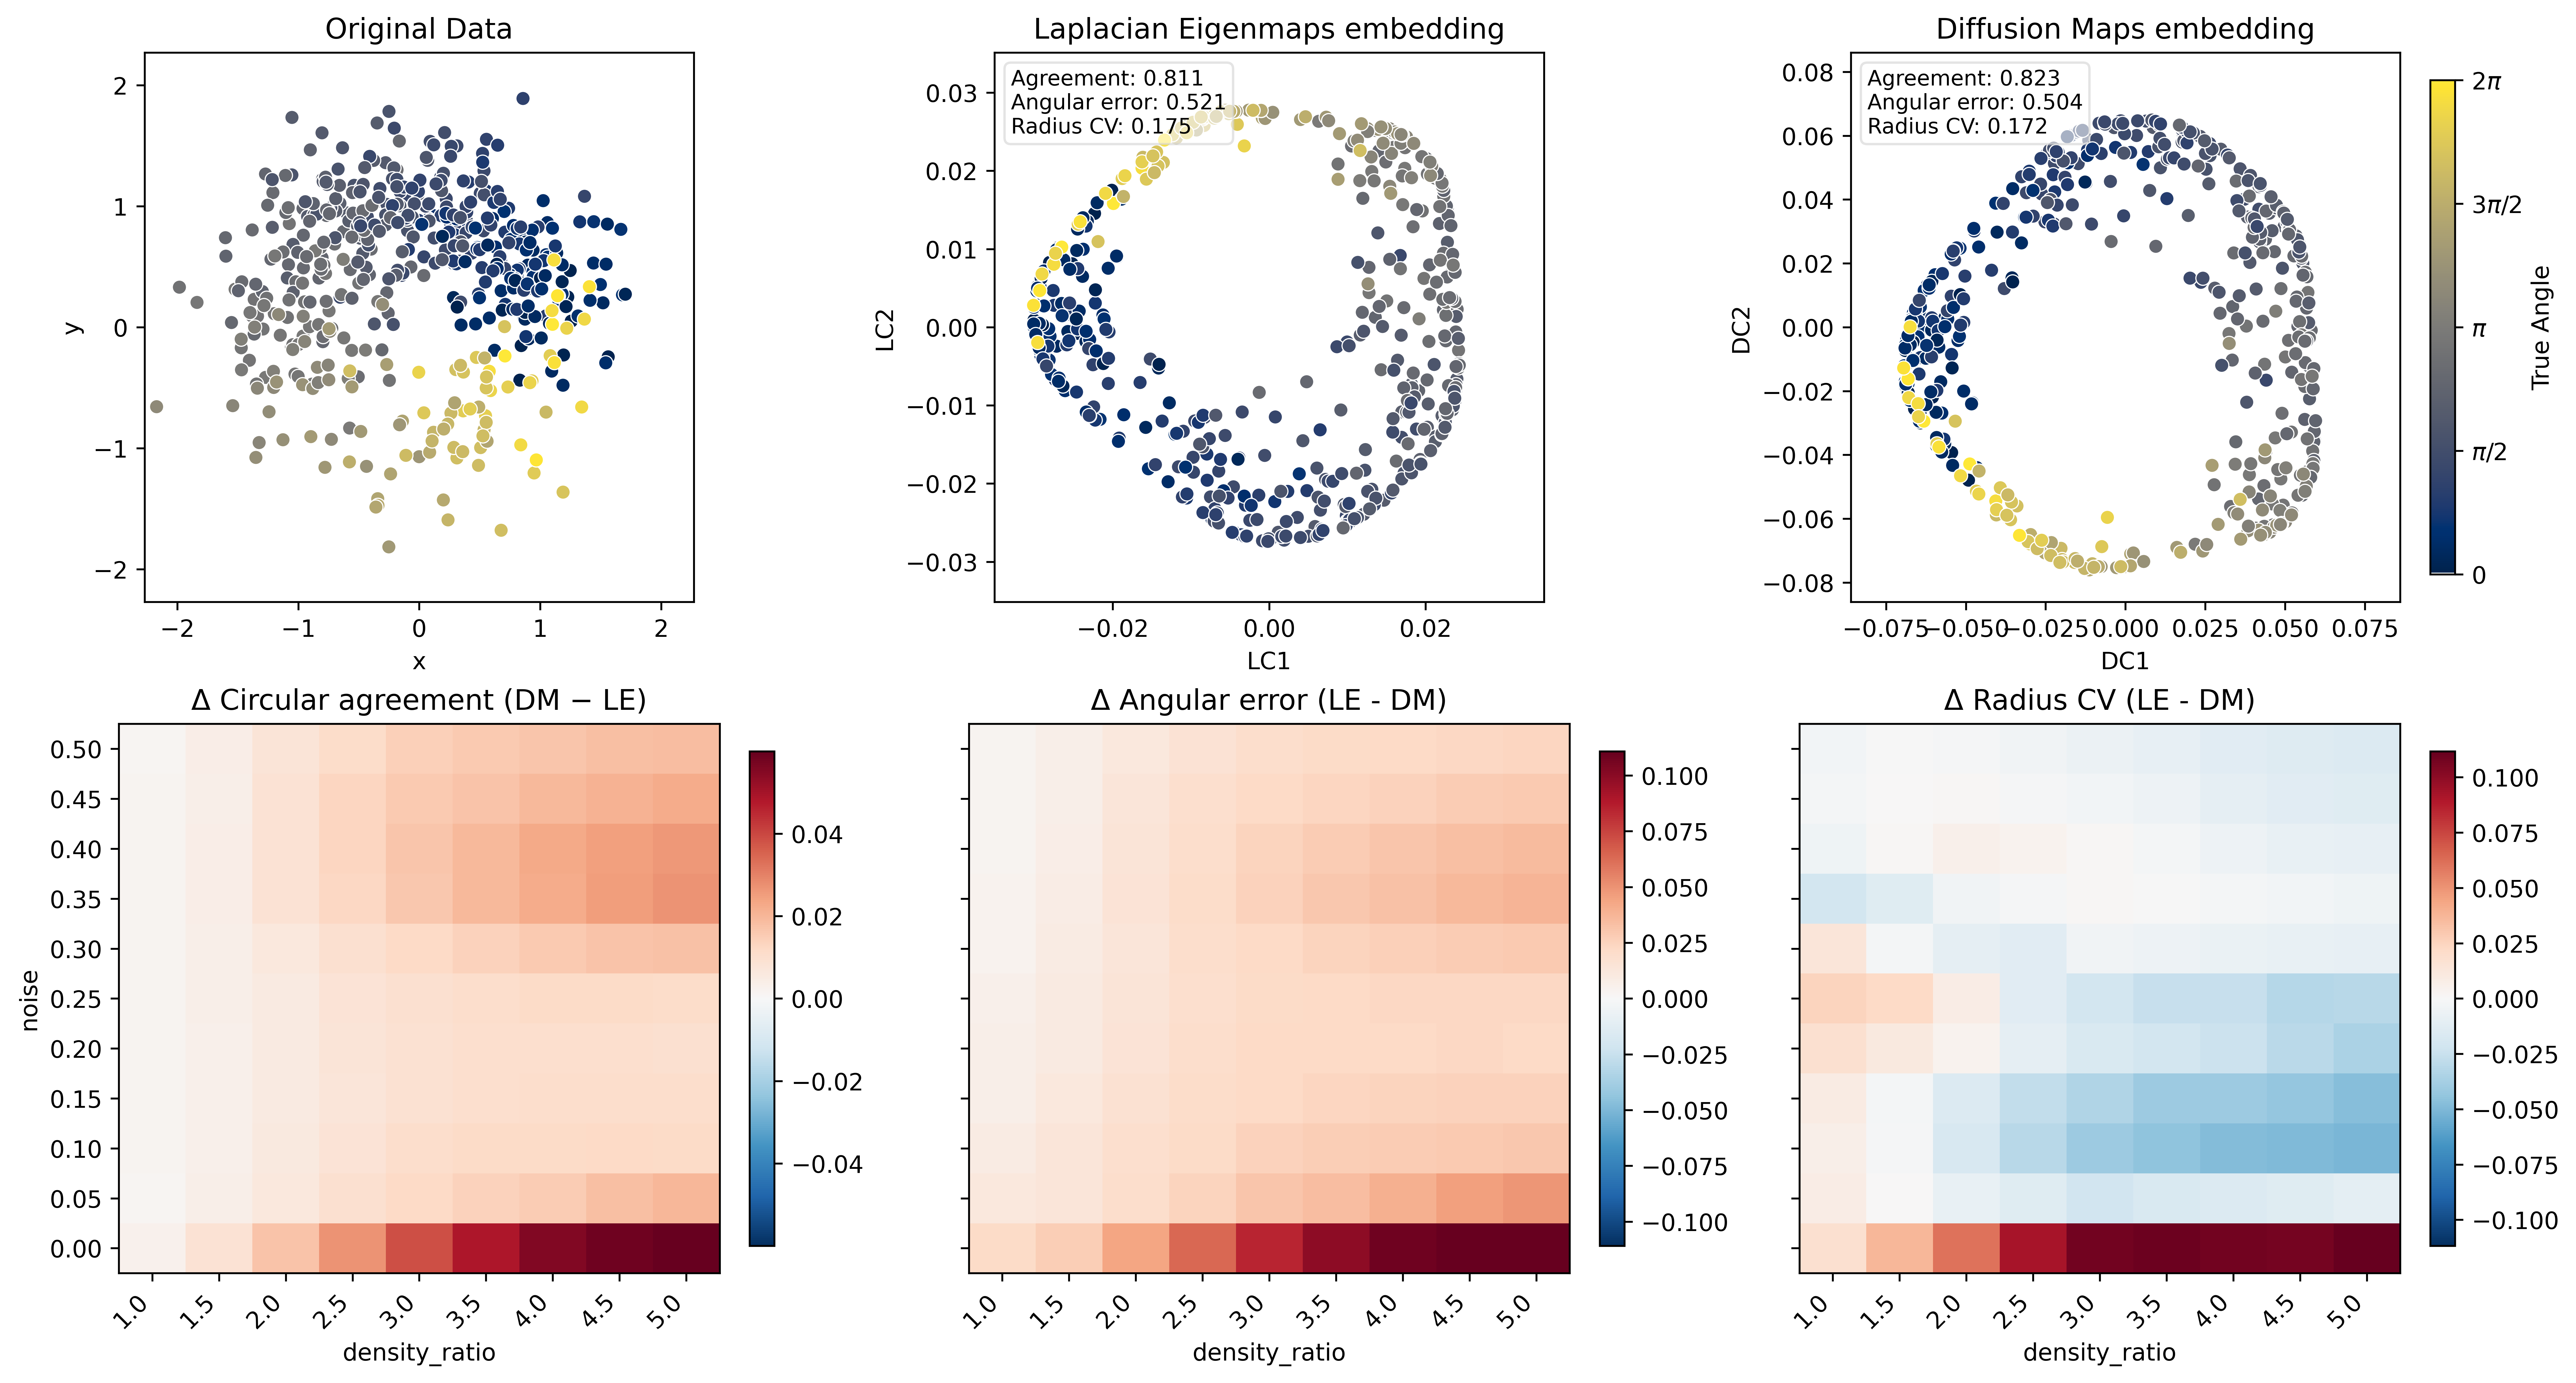

In [20]:
# plotting results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests



# file from running density_experiment.py
results = pd.read_csv('../data/toy_datasets/density_noise_exp_metrics_nogaussiankernel.csv')
results = results[results['k']==10]

# Assumes your dataframe is called df
# Columns:
# ['Method', 'aligned_circular_agreement', 'mean_abs_wrapped_error',
#  'radius_cv', 'noise', 'density_ratio', 'seed', 'k', 'n_points']

# trial-level paired differences
trial_wide = results.pivot_table(
    index=["noise", "density_ratio", "k", "seed"],
    columns="Method",
    values=[
        "aligned_circular_agreement",
        "mean_abs_wrapped_error",
        "radius_cv",
    ]
)

trial_wide.columns = [f"{metric}_{method}" for metric, method in trial_wide.columns]
trial_wide = trial_wide.reset_index()

trial_wide["agreement_diff_DM_minus_LE"] = (
    trial_wide["aligned_circular_agreement_DM"]
    - trial_wide["aligned_circular_agreement_LE"]
)

trial_wide["wrapped_error_advantage_DM"] = (
    trial_wide["mean_abs_wrapped_error_LE"]
    - trial_wide["mean_abs_wrapped_error_DM"]
)

trial_wide["radius_cv_advantage_DM"] = (
    trial_wide["radius_cv_LE"]
    - trial_wide["radius_cv_DM"]
)


trial_k_avg = (
    trial_wide
    .groupby(["noise", "density_ratio", "seed"], as_index=False)
    .agg({
        "agreement_diff_DM_minus_LE": "mean",
        "wrapped_error_advantage_DM": "mean",
        "radius_cv_advantage_DM": "mean",
    })
)

# -----------------------------
# 1) Aggregate over trials/seeds
# -----------------------------
summary = (
    results.groupby(["Method", "noise", "density_ratio", "k"], as_index=False)
      .agg(
          aligned_circular_agreement_mean=("aligned_circular_agreement", "mean"),
          aligned_circular_agreement_sem=("aligned_circular_agreement", "sem"),
          mean_abs_wrapped_error_mean=("mean_abs_wrapped_error", "mean"),
          mean_abs_wrapped_error_sem=("mean_abs_wrapped_error", "sem"),
          radius_cv_mean=("radius_cv", "mean"),
          radius_cv_sem=("radius_cv", "sem"),
      )
)

# -----------------------------
# 2) Difference tables: DM - LE
# -----------------------------
wide = summary.pivot_table(
    index=["noise", "density_ratio", "k"],
    columns="Method",
    values=[
        "aligned_circular_agreement_mean",
        "mean_abs_wrapped_error_mean",
        "radius_cv_mean",
    ]
)


# Flatten columns
wide.columns = [f"{metric}_{method}" for metric, method in wide.columns]
wide = wide.reset_index()

# Positive means DM better for all three derived metrics below
wide["agreement_diff_DM_minus_LE"] = (
    wide["aligned_circular_agreement_mean_DM"] - wide["aligned_circular_agreement_mean_LE"]
)
wide["wrapped_error_advantage_DM"] = (
    wide["mean_abs_wrapped_error_mean_LE"] - wide["mean_abs_wrapped_error_mean_DM"]
)
wide["radius_cv_advantage_DM"] = (
    wide["radius_cv_mean_LE"] - wide["radius_cv_mean_DM"]
)

# -----------------------------
# 2.5) Average over k
# -----------------------------
wide_k_avg = (
    wide.groupby(["noise", "density_ratio"], as_index=False)
        .agg({
            "agreement_diff_DM_minus_LE": "mean",
            "wrapped_error_advantage_DM": "mean",
            "radius_cv_advantage_DM": "mean",
        })
)

from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests
def compute_pvals(diff_df, value_col):
    rows = []
    for (n, d), sub in diff_df.groupby(["noise", "density_ratio"]):
        stat, p = ttest_1samp(sub[value_col], 0)
        rows.append({"noise": n, "density_ratio": d, "pval": p})
    return pd.DataFrame(rows)


metric_cols = [
    "agreement_diff_DM_minus_LE",
    "wrapped_error_advantage_DM",
    "radius_cv_advantage_DM",
]

def compute_all_pvals(diff_df, metric_cols, alternative="greater"):
    """
    diff_df should have one row per independent replicate:
        noise, density_ratio, seed, metric columns

    Here, trial_k_avg is appropriate because k has already been
    averaged within seed, so seeds are the independent units.
    """
    rows = []

    for metric in metric_cols:
        for (noise, density_ratio), sub in diff_df.groupby(["noise", "density_ratio"]):
            x = sub[metric].dropna().values

            if len(x) < 2:
                stat, p = np.nan, np.nan
            else:
                stat, p = ttest_1samp(
                    x,
                    popmean=0,
                    alternative=alternative,  # "greater" because positive = DM better
                )

            rows.append({
                "metric": metric,
                "noise": noise,
                "density_ratio": density_ratio,
                "n": len(x),
                "mean_diff": np.mean(x) if len(x) > 0 else np.nan,
                "stat": stat,
                "pval": p,
            })

    pval_df = pd.DataFrame(rows)

    valid = pval_df["pval"].notna()
    pval_df.loc[valid, "qval"] = multipletests(
        pval_df.loc[valid, "pval"],
        method="fdr_bh"
    )[1]

    return pval_df


all_pvals = compute_all_pvals(
    trial_k_avg,
    metric_cols,
    alternative="greater"
)
def add_fdr(pval_df):
    pval_df = pval_df.copy()
    pval_df["qval"] = multipletests(pval_df["pval"], method="fdr_bh")[1]
    return pval_df
# -----------------------------
# 3) Helper: single heatmap
# -----------------------------
def plot_heatmap_no_k(
    data,
    value_col,
    ax=None,
    title=None,
    cmap="cividis",
    vmin=None,
    vmax=None,
    pval_df=None,          # NEW: dataframe with p-values
    alpha=0.05,            # significance threshold
    star_marker="*",       # marker style
):
    heat = data.pivot(index="noise", columns="density_ratio", values=value_col)
    heat = heat.sort_index().sort_index(axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        heat.values,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels([f"{x:.1f}" for x in heat.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels([f"{y:.2f}" for y in heat.index])

    ax.set_xlabel("density_ratio")
    ax.set_ylabel("noise")
    ax.set_title(title)

        # -------------------------
    # ADD SIGNIFICANCE STARS
    # -------------------------
    if pval_df is not None:
        # pivot p-values to match heatmap layout
        pheat = pval_df.pivot(index="noise", columns="density_ratio", values="qval")
        pheat = pheat.reindex(index=heat.index, columns=heat.columns)

        for i, noise in enumerate(heat.index):
            for j, dr in enumerate(heat.columns):
                p = pheat.loc[noise, dr]

                if p < alpha:
                    ax.scatter(
                        j, i,
                        marker=star_marker,
                        color="black",
                        s=40,
                        linewidths=0.5,
                        edgecolors="white"
                    )

    return im



fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True,dpi=600)
axes = axes.flat

norm = plt.Normalize(adata.obs['angle'].min(), adata.obs['angle'].max())
sm = plt.cm.ScalarMappable(cmap="cividis", norm=norm)
sm.set_array([]) # Required for matplotlib versions

# Plotting high noise, variable density examples

dm_annot = metric_annot[metric_annot["Method"] == "DM"].iloc[0]
le_annot = metric_annot[metric_annot["Method"] == "LE"].iloc[0]
dm_text = (
    f"Agreement: {dm_annot['circular agreement']:.3f}\n"
    f"Angular error: {dm_annot['mean angular error']:.3f}\n"
    f"Radius CV: {dm_annot['radius CV']:.3f}"
)

le_text = (
    f"Agreement: {le_annot['circular agreement']:.3f}\n"
    f"Angular error: {le_annot['mean angular error']:.3f}\n"
    f"Radius CV: {le_annot['radius CV']:.3f}"
)

sns.scatterplot(x=adata.X[:,0],y=adata.X[:,1],ax=axes[0],hue=adata.obs['angle'],palette='cividis',legend=False)
axes[0].set_aspect('equal')
axes[0].set_title('Original Data')
max_range = np.max(np.abs(adata.X)) + 0.1
axes[0].set_xlim([-max_range,max_range])
axes[0].set_ylim([-max_range,max_range])
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
sns.scatterplot(x=adata.obsm['lap_embed'][:,0],y=adata.obsm['lap_embed'][:,1],hue=adata.obs['angle'],ax=axes[1],palette='cividis',legend=False)
axes[1].set_aspect('equal',adjustable='box')
axes[1].set_title('Laplacian Eigenmaps embedding')
max_range = np.max(np.abs(adata.obsm['lap_embed'][:,:2])) + 0.005
axes[1].set_xlim([-max_range,max_range])
axes[1].set_ylim([-max_range,max_range])
axes[1].set_xlabel('LC1')
axes[1].set_ylabel('LC2')
axes[1].text(
    0.03, 0.97,
    le_text,
    transform=axes[1].transAxes,
    va="top",
    ha="left",
    fontsize=9,
    fontweight='medium',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.6,
        edgecolor="lightgray"
    )
)

sns.scatterplot(x=adata.obsm['dm_embed'][:,0],y=adata.obsm['dm_embed'][:,1],hue=adata.obs['angle'],ax=axes[2],palette='cividis',legend=False)
axes[2].set_aspect('equal')
axes[2].set_title('Diffusion Maps embedding')
max_range = np.max(np.abs(adata.obsm['dm_embed'][:,:2])) + 0.01
axes[2].set_xlim([-max_range,max_range])
axes[2].set_ylim([-max_range,max_range])
axes[2].set_xlabel('DC1')
axes[2].set_ylabel('DC2')
axes[2].text(
    0.03, 0.97,
    dm_text,
    transform=axes[2].transAxes,
    va="top",
    ha="left",
    fontsize=9,
    fontweight='medium',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.6,
        edgecolor="lightgray"
    )
)
cb = axes[2].figure.colorbar(sm, ax=axes[2], label='True Angle',shrink=0.9)
ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
labels = ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
cb.set_ticks(ticks)
cb.set_ticklabels(labels)


# Plotting density experiment results
# symmetric color scales
mx1 = np.nanmax(np.abs(wide_k_avg["agreement_diff_DM_minus_LE"]))
mx2 = np.nanmax(np.abs(wide_k_avg["wrapped_error_advantage_DM"]))
mx3 = np.nanmax(np.abs(wide_k_avg["radius_cv_advantage_DM"]))
all_pvals = compute_all_pvals(trial_k_avg,metric_cols=metric_cols)
# pvals = add_fdr(compute_pvals(trial_k_avg, "agreement_diff_DM_minus_LE"))
# print(pvals)

im1 = plot_heatmap_no_k(
    wide_k_avg,
    "agreement_diff_DM_minus_LE",
    ax=axes[3],
    title="Δ Circular agreement (DM − LE)",
    cmap="RdBu_r",
    vmin=-mx1,
    vmax=mx1,
    # pval_df=all_pvals[all_pvals['metric']=='agreement_diff_DM_minus_LE'],
)
# pvals = add_fdr(compute_pvals(trial_k_avg, "wrapped_error_advantage_DM"))

im2 = plot_heatmap_no_k(
    wide_k_avg,
    "wrapped_error_advantage_DM",
    ax=axes[4],
    title="Δ Angular error (LE - DM)",
    cmap="RdBu_r",
    vmin=-mx2,
    vmax=mx2,
    # pval_df=all_pvals[all_pvals['metric']=='wrapped_error_advantage_DM'],
)
# pvals = add_fdr(compute_pvals(trial_k_avg, "radius_cv_advantage_DM"))

im3 = plot_heatmap_no_k(
    wide_k_avg,
    "radius_cv_advantage_DM",
    ax=axes[5],
    title="Δ Radius CV (LE - DM)",
    cmap="RdBu_r",
    vmin=-mx3,
    vmax=mx3,
    # pval_df=all_pvals[all_pvals['metric']=='radius_cv_advantage_DM'],
)
for ax in axes[4:6]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel('')
    ax.sharex(axes[4])
    ax.sharey(axes[4])
fig.colorbar(im1, ax=axes[3], shrink=0.9)
fig.colorbar(im2, ax=axes[4], shrink=0.9)
fig.colorbar(im3, ax=axes[5], shrink=0.9)
plt.show()